# DDT + Random 5%: Remaining Gap To Oracle

This notebook analyzes what is still missing after adding 5% randomly selected target labels to the DDT DAOD baseline.

Main comparisons:
- `DDT`: original DDT baseline, seed 42.
- `DDT + random 5%`: sparse random human-label injection, seed 42.
- `Oracle`: supervised target oracle.

Important note: the saved COCO-style summaries include overall `AP50`, but per-class entries are `AP-<class>`, not per-class AP50. So class-level analysis below uses per-class AP while overall headline numbers keep AP50.

In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / "runs").exists() and (path / "configs").exists():
            return path
    raise RuntimeError(f"Could not find project root from {start}")


PROJECT_ROOT = find_project_root()
RUNS = PROJECT_ROOT / "runs"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/local/home/ljzhang/code/SFADA')

In [3]:
MODEL_DIR = Path("cityscapes__to__foggy_cityscapes/dino_r50_4scale_12ep")

DDT_DIR = RUNS / "baselines/ddt_daod/ddt_daod_cityscapes_to_foggy_cityscapes_dino_seed42" / MODEL_DIR
RANDOM_DIR = RUNS / "baselines/ddt_daod/ddt_daod_cityscapes_to_foggy_cityscapes_dino_random_budget005_seed42" / MODEL_DIR
ORACLE_DIR = RUNS / "daod_oracle" / MODEL_DIR

RESULT_PATHS = {
    "DDT": DDT_DIR / "summary.json",
    "DDT + random 5%": RANDOM_DIR / "summary.json",
    "Oracle": ORACLE_DIR / "target_val_metrics.json",
}

for name, path in RESULT_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {name}: {path}")

RESULT_PATHS

{'DDT': PosixPath('/local/home/ljzhang/code/SFADA/runs/baselines/ddt_daod/ddt_daod_cityscapes_to_foggy_cityscapes_dino_seed42/cityscapes__to__foggy_cityscapes/dino_r50_4scale_12ep/summary.json'),
 'DDT + random 5%': PosixPath('/local/home/ljzhang/code/SFADA/runs/baselines/ddt_daod/ddt_daod_cityscapes_to_foggy_cityscapes_dino_random_budget005_seed42/cityscapes__to__foggy_cityscapes/dino_r50_4scale_12ep/summary.json'),
 'Oracle': PosixPath('/local/home/ljzhang/code/SFADA/runs/daod_oracle/cityscapes__to__foggy_cityscapes/dino_r50_4scale_12ep/target_val_metrics.json')}

In [4]:
def load_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def extract_bbox_metrics(path: Path) -> dict[str, float]:
    payload = load_json(path)
    if "final_target_val_metrics" in payload:
        return dict(payload["final_target_val_metrics"]["bbox"])
    if "target_val_metrics" in payload:
        return dict(payload["target_val_metrics"]["bbox"])
    if "bbox" in payload:
        return dict(payload["bbox"])
    raise KeyError(f"No bbox metrics found in {path}")


metrics = {name: extract_bbox_metrics(path) for name, path in RESULT_PATHS.items()}
metrics.keys()

dict_keys(['DDT', 'DDT + random 5%', 'Oracle'])

## Overall Gap

`DDT + random 5%` closes much of the AP50 gap, but the remaining oracle gap is still non-trivial. The table also shows whether the gain from random labels is mostly AP50, AP75, or object-scale dependent.

In [5]:
OVERALL_KEYS = ["AP", "AP50", "AP75", "APs", "APm", "APl"]

overall_df = pd.DataFrame(
    [{"method": name, **{key: metrics[name].get(key, np.nan) for key in OVERALL_KEYS}} for name in metrics]
).set_index("method")

overall_df.round(3)

,AP,AP50,AP75,APs,APm,APl
method,,,,,,
DDT,32.300,54.964,31.679,8.218,26.473,53.093
DDT + random 5%,36.100,59.811,35.316,9.494,30.426,56.790
Oracle,38.588,62.507,38.514,11.321,32.350,59.124


In [6]:
def safe_gap_closed(ddt: float, random_value: float, oracle: float) -> float:
    denom = oracle - ddt
    if abs(denom) < 1e-12:
        return np.nan
    return 100.0 * (random_value - ddt) / denom


gap_rows = []
for key in OVERALL_KEYS:
    ddt = metrics["DDT"][key]
    random_value = metrics["DDT + random 5%"][key]
    oracle = metrics["Oracle"][key]
    gap_rows.append(
        {
            "metric": key,
            "DDT": ddt,
            "DDT + random 5%": random_value,
            "Oracle": oracle,
            "gain_from_random": random_value - ddt,
            "remaining_to_oracle": oracle - random_value,
            "gap_closed_%": safe_gap_closed(ddt, random_value, oracle),
        }
    )

gap_df = pd.DataFrame(gap_rows).set_index("metric")
gap_df.round(3)

,DDT,DDT + random 5%,Oracle,gain_from_random,remaining_to_oracle,gap_closed_%
metric,,,,,,
AP,32.300,36.100,38.588,3.801,2.488,60.438
AP50,54.964,59.811,62.507,4.847,2.696,64.256
AP75,31.679,35.316,38.514,3.636,3.199,53.202
APs,8.218,9.494,11.321,1.277,1.827,41.143
APm,26.473,30.426,32.350,3.953,1.924,67.255
APl,53.093,56.790,59.124,3.697,2.334,61.300


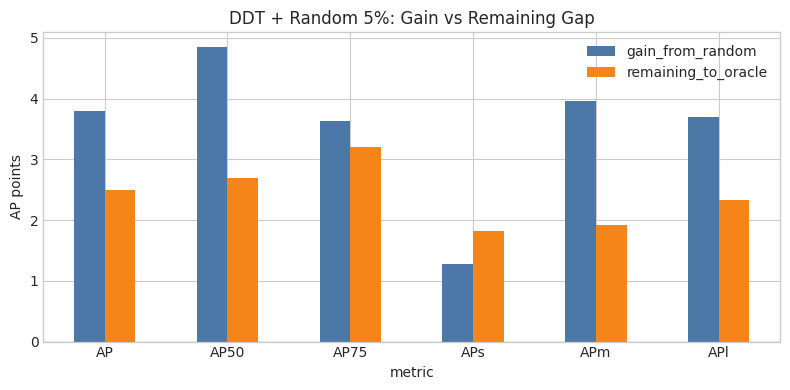

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
gap_df[["gain_from_random", "remaining_to_oracle"]].plot(kind="bar", ax=ax, color=["#4C78A8", "#F58518"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("AP points")
ax.set_title("DDT + Random 5%: Gain vs Remaining Gap")
ax.legend(loc="best")
plt.xticks(rotation=0)
plt.tight_layout()

## Per-Class Gap

These are per-class AP values from the saved COCO summary. This is still useful for diagnosing whether the remaining oracle gap is concentrated in rare/hard classes.

In [8]:
CLASSES = ["person", "rider", "car", "truck", "bus", "train", "motorcycle", "bicycle"]

class_rows = []
for class_name in CLASSES:
    key = f"AP-{class_name}"
    ddt = metrics["DDT"][key]
    random_value = metrics["DDT + random 5%"][key]
    oracle = metrics["Oracle"][key]
    class_rows.append(
        {
            "class": class_name,
            "DDT": ddt,
            "DDT + random 5%": random_value,
            "Oracle": oracle,
            "gain_from_random": random_value - ddt,
            "remaining_to_oracle": oracle - random_value,
            "gap_closed_%": safe_gap_closed(ddt, random_value, oracle),
        }
    )

class_gap_df = pd.DataFrame(class_rows).set_index("class")
class_gap_df.sort_values("remaining_to_oracle", ascending=False).round(3)

,DDT,DDT + random 5%,Oracle,gain_from_random,remaining_to_oracle,gap_closed_%
class,,,,,,
car,46.728,51.526,56.198,4.798,4.673,50.662
train,19.760,21.903,26.178,2.143,4.275,33.397
truck,26.513,31.533,35.137,5.020,3.604,58.209
motorcycle,19.143,23.755,26.928,4.611,3.174,59.234
person,33.393,36.367,38.583,2.974,2.216,57.297
rider,39.207,39.561,41.643,0.354,2.082,14.517
bicycle,28.433,30.483,31.668,2.050,1.185,63.370
bus,45.221,53.676,52.371,8.455,-1.305,118.257


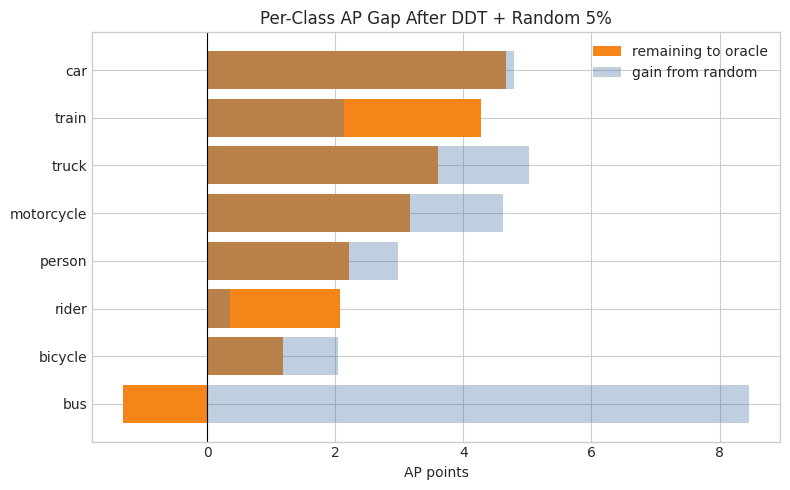

In [9]:
plot_df = class_gap_df.sort_values("remaining_to_oracle", ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_df.index, plot_df["remaining_to_oracle"], color="#F58518", label="remaining to oracle")
ax.barh(plot_df.index, plot_df["gain_from_random"], left=0, color="#4C78A8", alpha=0.35, label="gain from random")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("AP points")
ax.set_title("Per-Class AP Gap After DDT + Random 5%")
ax.legend(loc="best")
plt.tight_layout()

## Scale Gap

This tells us whether the remaining gap is mostly small/medium/large object behavior. If one scale dominates, the next method should probably target that failure mode rather than generic pseudo-label surgery.

In [10]:
scale_df = gap_df.loc[["APs", "APm", "APl"]].copy()
scale_df.index = ["small", "medium", "large"]
scale_df.round(3)

,DDT,DDT + random 5%,Oracle,gain_from_random,remaining_to_oracle,gap_closed_%
small,8.218,9.494,11.321,1.277,1.827,41.143
medium,26.473,30.426,32.350,3.953,1.924,67.255
large,53.093,56.790,59.124,3.697,2.334,61.300


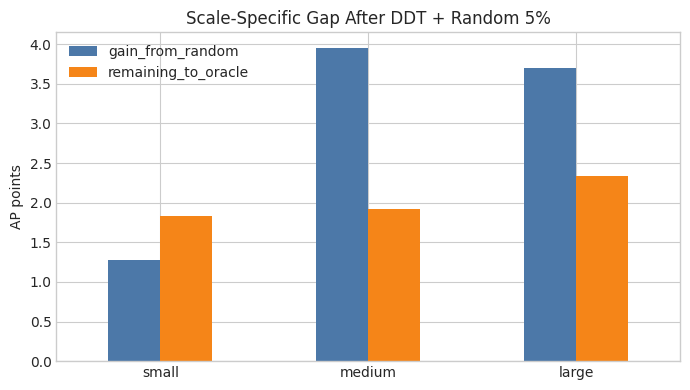

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
scale_df[["gain_from_random", "remaining_to_oracle"]].plot(kind="bar", ax=ax, color=["#4C78A8", "#F58518"])
ax.set_ylabel("AP points")
ax.set_title("Scale-Specific Gap After DDT + Random 5%")
plt.xticks(rotation=0)
plt.tight_layout()

## Optional: What Did The Random 5% Labels Contain?

This section loads the selected target ids and materializes the target training split to count GT objects in the selected 5%. If it fails because the local dataset registry is unavailable, the metric-gap sections above still work.

In [15]:
selected_ids_path = RANDOM_DIR / "selected_target_ids.json"
resolved_config_path = RANDOM_DIR / "resolved_config.yaml"

selected_payload = load_json(selected_ids_path)
selected_ids = set(selected_payload["selected_ids"])
print(f"Selected {selected_payload['selected_count']} / {selected_payload['target_total']} target images")

label_count_df = None
try:
    from src.config import load_config
    from src.data.daod.detectron2 import materialize_daod_dicts

    cfg = load_config(str(resolved_config_path))
    data_root_candidates = [
        Path(getattr(cfg.data, "root", "")),
        Path.home() / "data/ins-seg/cityscapes",
        Path("/home/ljzhang/data/ins-seg/cityscapes"),
        Path("/local/home/ljzhang/data/ins-seg/cityscapes"),
    ]
    for candidate in data_root_candidates:
        if (candidate / "leftImg8bit_foggy" / "train").exists():
            if str(candidate) != str(cfg.data.root):
                print(f"Overriding data.root: {cfg.data.root} -> {candidate}")
            cfg.data.root = str(candidate)
            break
    else:
        checked = [str(path) for path in data_root_candidates]
        raise FileNotFoundError(f"Could not find local Cityscapes foggy train dir under: {checked}")
    target_train = materialize_daod_dicts(cfg, "target_train")

    selected_object_counts = Counter()
    target_object_counts = Counter()
    selected_image_counts = Counter()
    target_image_counts = Counter()

    for sample in target_train:
        sample_id = str(sample["sample_id"])
        classes_in_image = set()
        for ann in sample.get("annotations", []):
            class_id = int(ann["category_id"])
            target_object_counts[class_id] += 1
            classes_in_image.add(class_id)
            if sample_id in selected_ids:
                selected_object_counts[class_id] += 1
        for class_id in classes_in_image:
            target_image_counts[class_id] += 1
            if sample_id in selected_ids:
                selected_image_counts[class_id] += 1

    label_rows = []
    for class_id, class_name in enumerate(CLASSES):
        selected_objects = selected_object_counts[class_id]
        target_objects = target_object_counts[class_id]
        label_rows.append(
            {
                "class": class_name,
                "selected_objects": selected_objects,
                "target_objects": target_objects,
                "selected_object_%": 100.0 * selected_objects / max(target_objects, 1),
                "selected_images_with_class": selected_image_counts[class_id],
                "target_images_with_class": target_image_counts[class_id],
                "selected_image_%": 100.0 * selected_image_counts[class_id] / max(target_image_counts[class_id], 1),
            }
        )
    label_count_df = pd.DataFrame(label_rows).set_index("class")
    display(label_count_df.round(3))
except Exception as exc:
    print(f"Skipping selected-label composition analysis: {type(exc).__name__}: {exc}")

Selected 149 / 2975 target images
Overriding data.root: /opt/ml/input/data/data -> /home/ljzhang/data/ins-seg/cityscapes


,selected_objects,target_objects,selected_object_%,selected_images_with_class,target_images_with_class,selected_image_%
class,,,,,,
person,1157,17994,6.430,122,2326,5.245
rider,76,1807,4.206,49,1024,4.785
car,1409,27155,5.189,137,2831,4.839
truck,45,489,9.202,27,363,7.438
bus,16,385,4.156,13,276,4.710
train,9,171,5.263,7,145,4.828
motorcycle,33,739,4.465,25,511,4.892
bicycle,166,3729,4.452,82,1538,5.332


,DDT,DDT + random 5%,Oracle,gain_from_random,remaining_to_oracle,gap_closed_%,selected_objects,target_objects,selected_object_%,selected_images_with_class,target_images_with_class,selected_image_%
class,,,,,,,,,,,,
car,46.728,51.526,56.198,4.798,4.673,50.662,1409,27155,5.189,137,2831,4.839
train,19.760,21.903,26.178,2.143,4.275,33.397,9,171,5.263,7,145,4.828
truck,26.513,31.533,35.137,5.020,3.604,58.209,45,489,9.202,27,363,7.438
motorcycle,19.143,23.755,26.928,4.611,3.174,59.234,33,739,4.465,25,511,4.892
person,33.393,36.367,38.583,2.974,2.216,57.297,1157,17994,6.430,122,2326,5.245
rider,39.207,39.561,41.643,0.354,2.082,14.517,76,1807,4.206,49,1024,4.785
bicycle,28.433,30.483,31.668,2.050,1.185,63.370,166,3729,4.452,82,1538,5.332
bus,45.221,53.676,52.371,8.455,-1.305,118.257,16,385,4.156,13,276,4.710


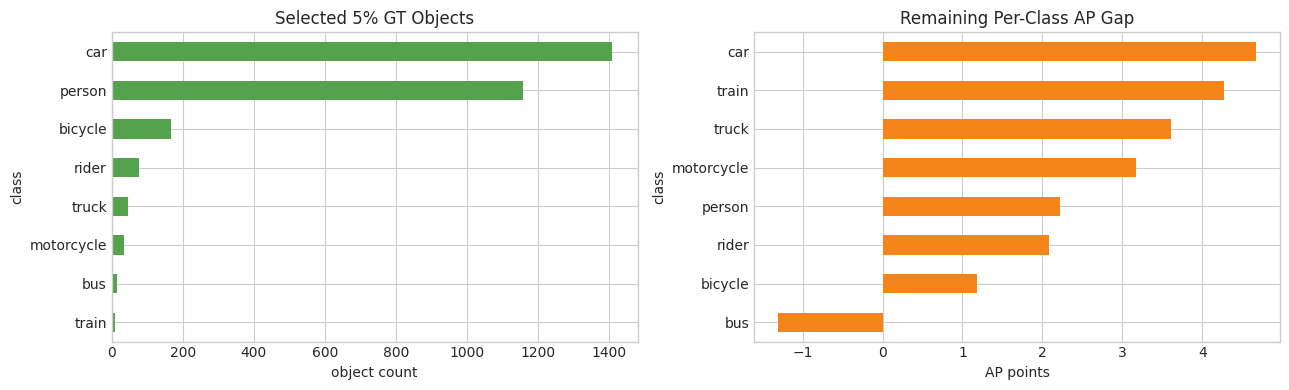

In [16]:
if label_count_df is not None:
    joined = class_gap_df.join(label_count_df)
    display(joined.sort_values("remaining_to_oracle", ascending=False).round(3))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    joined.sort_values("selected_objects")["selected_objects"].plot(kind="barh", ax=axes[0], color="#54A24B")
    axes[0].set_title("Selected 5% GT Objects")
    axes[0].set_xlabel("object count")

    joined.sort_values("remaining_to_oracle")["remaining_to_oracle"].plot(kind="barh", ax=axes[1], color="#F58518")
    axes[1].set_title("Remaining Per-Class AP Gap")
    axes[1].set_xlabel("AP points")
    plt.tight_layout()

## Selected-Label Pseudo Quality Audit

This section uses only the randomly selected 5% human-labeled target images as a small audit set. It loads the final `DDT + random 5%` teacher, generates DDT-style pseudo labels with the saved final thresholds, and matches those pseudo labels to the selected GT at IoU 0.5.

Caveat: this is a diagnostic, not an oracle method. It uses labels that are already available during training, but it evaluates the final teacher/thresholds rather than reconstructing every training-time pseudo-label update.

In [18]:
AUDIT_IOU_THRESH = 0.50
AUDIT_NEARBY_IOU_THRESH = 0.10
AUDIT_FORCE_RECOMPUTE = False
AUDIT_CACHE_PATH = RANDOM_DIR / "selected_label_pseudo_quality_audit.json"


def apply_local_cityscapes_root(cfg):
    data_root_candidates = [
        Path(getattr(cfg.data, "root", "")),
        Path.home() / "data/ins-seg/cityscapes",
        Path("/home/ljzhang/data/ins-seg/cityscapes"),
        Path("/local/home/ljzhang/data/ins-seg/cityscapes"),
    ]
    for candidate in data_root_candidates:
        if (candidate / "leftImg8bit_foggy" / "train").exists():
            if str(candidate) != str(cfg.data.root):
                print(f"Overriding data.root: {cfg.data.root} -> {candidate}")
            cfg.data.root = str(candidate)
            return cfg
    checked = [str(path) for path in data_root_candidates]
    raise FileNotFoundError(f"Could not find local Cityscapes foggy train dir under: {checked}")


def ensure_selected_target_train():
    global cfg, target_train, selected_payload, selected_ids, resolved_config_path
    if "resolved_config_path" not in globals():
        resolved_config_path = RANDOM_DIR / "resolved_config.yaml"
    if "selected_ids" not in globals():
        selected_payload = load_json(RANDOM_DIR / "selected_target_ids.json")
        selected_ids = set(selected_payload["selected_ids"])
    if "cfg" not in globals():
        from src.config import load_config

        cfg = load_config(str(resolved_config_path))
    cfg = apply_local_cityscapes_root(cfg)
    if "target_train" not in globals():
        from src.data.daod.detectron2 import materialize_daod_dicts

        target_train = materialize_daod_dicts(cfg, "target_train")
    selected_samples = [sample for sample in target_train if str(sample["sample_id"]) in selected_ids]
    print(f"Selected audit images: {len(selected_samples)}")
    return selected_samples


def compact_gt_annotation(ann: dict) -> dict:
    category_id = int(ann["category_id"])
    return {
        "bbox": [float(value) for value in ann["bbox"]],
        "category_id": category_id,
        "category_name": CLASSES[category_id],
        "area": float(ann.get("area", 0.0)),
    }


def compact_pseudo_row(row: dict) -> dict:
    category_id = int(row["category_id"])
    return {
        "bbox": [float(value) for value in row["bbox"]],
        "score": float(row["score"]),
        "category_id": category_id,
        "category_name": CLASSES[category_id],
    }


def build_selected_label_pseudo_audit(selected_samples: list[dict]) -> dict:
    import random

    import torch
    from detectron2.checkpoint import DetectionCheckpointer
    from PIL import Image

    from baselines.ddt_daod.pseudo import filter_pseudo_rows
    from src.data.daod import build_weak_view_sample, map_boxes_to_original_view
    from src.data.daod.analysis import raw_output_to_query_rows
    from src.models import build_daod_model, run_daod_raw_outputs

    summary_payload = load_json(RANDOM_DIR / "summary.json")
    pseudo_thresholds = list(
        summary_payload.get("effective_thresholds")
        or summary_payload.get("ddt_thresholds")
        or summary_payload.get("thresholds")
        or [0.4 for _ in CLASSES]
    )
    dedup_iou_thresh = float(getattr(getattr(cfg.method, "pseudo", object()), "dedup_iou_thresh", 0.7))
    teacher_checkpoint = RANDOM_DIR / "teacher_last.pth"
    if not teacher_checkpoint.exists():
        raise FileNotFoundError(f"Missing teacher checkpoint: {teacher_checkpoint}")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Loading DDT+random teacher on {device}: {teacher_checkpoint}")
    teacher_adapter = build_daod_model(cfg, load_weights=False, device=device)
    DetectionCheckpointer(teacher_adapter.model).load(str(teacher_checkpoint))
    teacher_adapter.model.eval()

    weak_rng = random.Random(int(getattr(cfg, "seed", 42)) + 1009)
    sample_payloads = []
    for index, sample in enumerate(selected_samples, start=1):
        image = Image.open(sample["file_name"]).convert("RGB")
        weak_sample = build_weak_view_sample(
            {**sample, "image": image},
            rng=weak_rng,
            suffix="audit_teacher_weak",
        )
        raw_output = run_daod_raw_outputs(teacher_adapter, weak_sample, with_grad=False)[0]
        query_rows = raw_output_to_query_rows(
            raw_output,
            image_size=(int(sample["height"]), int(sample["width"])),
        )
        weak_meta = weak_sample["view_meta"]
        if weak_meta.get("hflip", False):
            mapped_boxes = map_boxes_to_original_view([row["bbox"] for row in query_rows], weak_meta)
            for row, box in zip(query_rows, mapped_boxes):
                row["bbox"] = box
        pseudo_rows = filter_pseudo_rows(
            query_rows,
            thresholds=pseudo_thresholds,
            dedup_iou_thresh=dedup_iou_thresh,
        )
        sample_payloads.append(
            {
                "sample_id": str(sample["sample_id"]),
                "file_name": str(sample["file_name"]),
                "weak_hflip": bool(weak_meta.get("hflip", False)),
                "gt_rows": [compact_gt_annotation(ann) for ann in sample.get("annotations", [])],
                "pseudo_rows": [compact_pseudo_row(row) for row in pseudo_rows],
            }
        )
        if index == 1 or index % 25 == 0 or index == len(selected_samples):
            print(f"Audited {index}/{len(selected_samples)} selected images")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return {
        "iou_thresh": AUDIT_IOU_THRESH,
        "nearby_iou_thresh": AUDIT_NEARBY_IOU_THRESH,
        "thresholds": [float(value) for value in pseudo_thresholds],
        "dedup_iou_thresh": dedup_iou_thresh,
        "teacher_checkpoint": str(teacher_checkpoint),
        "num_images": len(sample_payloads),
        "samples": sample_payloads,
    }


pseudo_quality_df = None
pseudo_confusion_df = None
if AUDIT_CACHE_PATH.exists() and not AUDIT_FORCE_RECOMPUTE:
    print(f"Loading cached audit: {AUDIT_CACHE_PATH}")
    audit_payload = load_json(AUDIT_CACHE_PATH)
else:
    selected_samples = ensure_selected_target_train()
    audit_payload = build_selected_label_pseudo_audit(selected_samples)
    AUDIT_CACHE_PATH.write_text(json.dumps(audit_payload, indent=2), encoding="utf-8")
    print(f"Saved audit cache: {AUDIT_CACHE_PATH}")

print(
    f"Audit pseudo thresholds: "
    f"{[round(value, 3) for value in audit_payload['thresholds']]} "
    f"on {audit_payload['num_images']} selected images"
)

Selected audit images: 149
Loading DDT+random teacher on cuda: /local/home/ljzhang/code/SFADA/runs/baselines/ddt_daod/ddt_daod_cityscapes_to_foggy_cityscapes_dino_random_budget005_seed42/cityscapes__to__foggy_cityscapes/dino_r50_4scale_12ep/teacher_last.pth


/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Audited 1/149 selected images
Audited 25/149 selected images
Audited 50/149 selected images
Audited 75/149 selected images
Audited 100/149 selected images
Audited 125/149 selected images
Audited 149/149 selected images
Saved audit cache: /local/home/ljzhang/code/SFADA/runs/baselines/ddt_daod/ddt_daod_cityscapes_to_foggy_cityscapes_dino_random_budget005_seed42/cityscapes__to__foggy_cityscapes/dino_r50_4scale_12ep/selected_label_pseudo_quality_audit.json
Audit pseudo thresholds: [0.406, 0.407, 0.409, 0.401, 0.407, 0.406, 0.404, 0.403] on 149 selected images


In [19]:
from collections import Counter

from src.data.daod.analysis import greedy_match_rows, xyxy_iou


def summarize_selected_label_pseudo_quality(audit_payload: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    iou_thresh = float(audit_payload.get("iou_thresh", AUDIT_IOU_THRESH))
    nearby_iou_thresh = float(audit_payload.get("nearby_iou_thresh", AUDIT_NEARBY_IOU_THRESH))
    stats = {
        class_id: Counter(
            {
                "gt_count": 0,
                "pseudo_count": 0,
                "tp": 0,
                "fp": 0,
                "fn": 0,
                "matched_iou_sum": 0.0,
                "miss_count": 0,
                "wrong_class_count": 0,
                "localization_error_count": 0,
                "localization_error_iou_sum": 0.0,
                "background_fp_count": 0,
                "duplicate_fp_count": 0,
                "class_confusion_fp_count": 0,
            }
        )
        for class_id in range(len(CLASSES))
    }
    confusion_counts = Counter()

    for sample_payload in audit_payload["samples"]:
        gt_rows = sample_payload["gt_rows"]
        pred_rows = sample_payload["pseudo_rows"]
        for gt in gt_rows:
            stats[int(gt["category_id"])]["gt_count"] += 1
        for pred in pred_rows:
            stats[int(pred["category_id"])]["pseudo_count"] += 1

        matches, unmatched_gt, unmatched_pred = greedy_match_rows(
            gt_rows,
            pred_rows,
            iou_thresh=iou_thresh,
            class_aware=True,
        )
        for match in matches:
            class_id = int(match["left"]["category_id"])
            stats[class_id]["tp"] += 1
            stats[class_id]["matched_iou_sum"] += float(match["iou"])

        for gt_index in unmatched_gt:
            gt = gt_rows[gt_index]
            class_id = int(gt["category_id"])
            stats[class_id]["fn"] += 1
            nearby_iou = 0.0
            same_class_nearby_iou = 0.0
            for pred in pred_rows:
                iou = xyxy_iou(gt["bbox"], pred["bbox"])
                nearby_iou = max(nearby_iou, iou)
                if int(pred["category_id"]) == class_id:
                    same_class_nearby_iou = max(same_class_nearby_iou, iou)
            if same_class_nearby_iou >= nearby_iou_thresh:
                stats[class_id]["localization_error_count"] += 1
                stats[class_id]["localization_error_iou_sum"] += same_class_nearby_iou
            elif nearby_iou >= nearby_iou_thresh:
                stats[class_id]["wrong_class_count"] += 1
            else:
                stats[class_id]["miss_count"] += 1

        for pred_index in unmatched_pred:
            pred = pred_rows[pred_index]
            class_id = int(pred["category_id"])
            stats[class_id]["fp"] += 1
            max_iou_any_gt = 0.0
            max_iou_same_class_gt = 0.0
            for gt in gt_rows:
                iou = xyxy_iou(pred["bbox"], gt["bbox"])
                max_iou_any_gt = max(max_iou_any_gt, iou)
                if int(gt["category_id"]) == class_id:
                    max_iou_same_class_gt = max(max_iou_same_class_gt, iou)
            if max_iou_any_gt < nearby_iou_thresh:
                stats[class_id]["background_fp_count"] += 1
            elif max_iou_same_class_gt >= nearby_iou_thresh:
                stats[class_id]["duplicate_fp_count"] += 1
            else:
                stats[class_id]["class_confusion_fp_count"] += 1

        class_agnostic_matches, _, _ = greedy_match_rows(
            gt_rows,
            pred_rows,
            iou_thresh=iou_thresh,
            class_aware=False,
        )
        for match in class_agnostic_matches:
            gt_class = int(match["left"]["category_id"])
            pred_class = int(match["right"]["category_id"])
            if gt_class != pred_class:
                confusion_counts[(CLASSES[gt_class], CLASSES[pred_class])] += 1

    quality_rows = []
    for class_id, class_name in enumerate(CLASSES):
        row = dict(stats[class_id])
        tp = float(row["tp"])
        fp = float(row["fp"])
        gt_count = float(row["gt_count"])
        row["class"] = class_name
        row["precision"] = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        row["recall"] = tp / gt_count if gt_count > 0 else np.nan
        row["fn_rate"] = float(row["fn"]) / gt_count if gt_count > 0 else np.nan
        row["miss_rate"] = float(row["miss_count"]) / gt_count if gt_count > 0 else np.nan
        row["wrong_class_rate"] = float(row["wrong_class_count"]) / gt_count if gt_count > 0 else np.nan
        row["localization_error_rate"] = float(row["localization_error_count"]) / gt_count if gt_count > 0 else np.nan
        row["matched_iou_mean"] = float(row["matched_iou_sum"]) / tp if tp > 0 else np.nan
        row["localization_error_iou_mean"] = (
            float(row["localization_error_iou_sum"]) / float(row["localization_error_count"])
            if row["localization_error_count"] > 0
            else np.nan
        )
        quality_rows.append(row)

    quality_df = pd.DataFrame(quality_rows).set_index("class")
    confusion_rows = [
        {"gt_class": gt_class, "pred_class": pred_class, "count": count}
        for (gt_class, pred_class), count in confusion_counts.items()
    ]
    confusion_df = pd.DataFrame(confusion_rows, columns=["gt_class", "pred_class", "count"])
    if len(confusion_df) > 0:
        confusion_df = confusion_df.sort_values("count", ascending=False)
    return quality_df, confusion_df


pseudo_quality_df, pseudo_confusion_df = summarize_selected_label_pseudo_quality(audit_payload)
audit_view = class_gap_df[["DDT + random 5%", "Oracle", "gain_from_random", "remaining_to_oracle"]].join(pseudo_quality_df)
if "label_count_df" in globals() and label_count_df is not None:
    audit_view = audit_view.join(label_count_df[["selected_objects", "selected_images_with_class"]])

main_cols = [
    "remaining_to_oracle",
    "selected_objects",
    "selected_images_with_class",
    "gt_count",
    "pseudo_count",
    "tp",
    "fp",
    "fn",
    "precision",
    "recall",
    "matched_iou_mean",
    "miss_rate",
    "wrong_class_rate",
    "localization_error_rate",
]
main_cols = [col for col in main_cols if col in audit_view.columns]
display(audit_view[main_cols].sort_values("remaining_to_oracle", ascending=False).round(3))

,remaining_to_oracle,selected_objects,selected_images_with_class,gt_count,pseudo_count,tp,fp,fn,precision,recall,matched_iou_mean,miss_rate,wrong_class_rate,localization_error_rate
class,,,,,,,,,,,,,,
car,4.673,1409,137,1409,1203,1103,100,306,0.917,0.783,0.876,0.092,0.004,0.121
train,4.275,9,7,9,4,4,0,5,1.000,0.444,0.970,0.556,0.000,0.000
truck,3.604,45,27,45,17,16,1,29,0.941,0.356,0.909,0.356,0.244,0.044
motorcycle,3.174,33,25,33,23,19,4,14,0.826,0.576,0.866,0.121,0.182,0.121
person,2.216,1157,122,1157,898,807,91,350,0.899,0.697,0.848,0.163,0.010,0.129
rider,2.082,76,49,76,58,55,3,21,0.948,0.724,0.870,0.092,0.132,0.053
bicycle,1.185,166,82,166,136,116,20,50,0.853,0.699,0.861,0.139,0.072,0.090
bus,-1.305,16,13,16,12,11,1,5,0.917,0.688,0.895,0.188,0.125,0.000


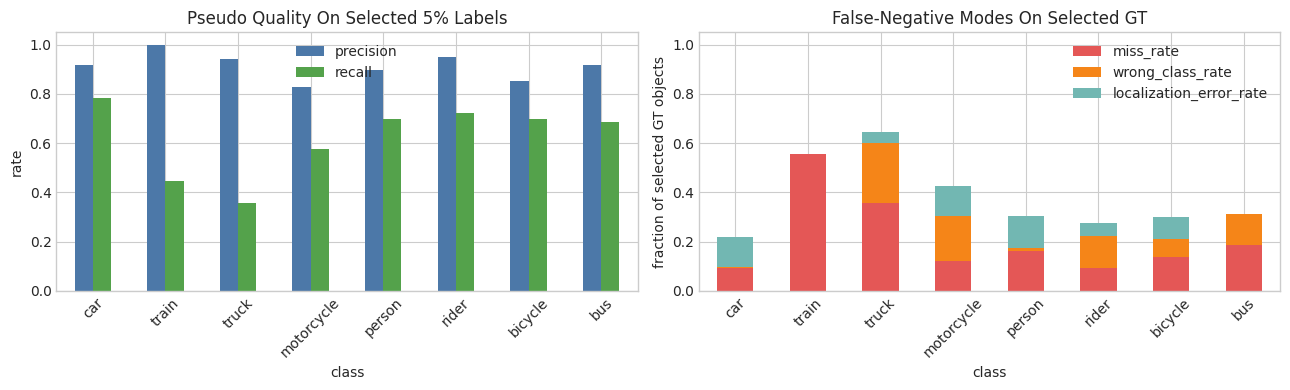

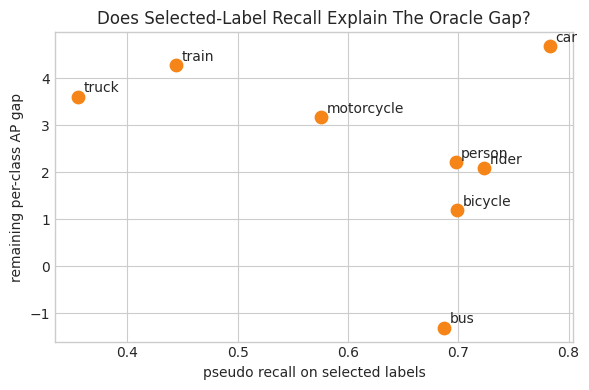

In [20]:
if pseudo_quality_df is not None:
    plot_quality = audit_view.sort_values("remaining_to_oracle", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    plot_quality[["precision", "recall"]].plot(kind="bar", ax=axes[0], color=["#4C78A8", "#54A24B"])
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title("Pseudo Quality On Selected 5% Labels")
    axes[0].set_ylabel("rate")
    axes[0].tick_params(axis="x", rotation=45)

    error_rate_cols = ["miss_rate", "wrong_class_rate", "localization_error_rate"]
    plot_quality[error_rate_cols].plot(kind="bar", stacked=True, ax=axes[1], color=["#E45756", "#F58518", "#72B7B2"])
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title("False-Negative Modes On Selected GT")
    axes[1].set_ylabel("fraction of selected GT objects")
    axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(audit_view["recall"], audit_view["remaining_to_oracle"], s=80, color="#F58518")
    for class_name, row in audit_view.iterrows():
        if pd.notna(row["recall"]) and pd.notna(row["remaining_to_oracle"]):
            ax.annotate(class_name, (row["recall"], row["remaining_to_oracle"]), xytext=(4, 3), textcoords="offset points")
    ax.set_xlabel("pseudo recall on selected labels")
    ax.set_ylabel("remaining per-class AP gap")
    ax.set_title("Does Selected-Label Recall Explain The Oracle Gap?")
    plt.tight_layout()

In [21]:
if pseudo_confusion_df is not None and len(pseudo_confusion_df) > 0:
    print("Top class confusions among matched selected-label objects:")
    display(pseudo_confusion_df.head(12))
else:
    print("No class confusions at IoU >= 0.50 on the selected-label audit set.")

Top class confusions among matched selected-label objects:


,gt_class,pred_class,count
2,rider,person,4
0,bus,car,1
1,bicycle,car,1
3,person,rider,1


## Auto-Summary

Use this cell for the high-level readout after running the notebook.

In [22]:
ap50_gap = gap_df.loc["AP50"]
print(
    f"AP50: DDT={ap50_gap['DDT']:.3f}, "
    f"DDT+random={ap50_gap['DDT + random 5%']:.3f}, "
    f"Oracle={ap50_gap['Oracle']:.3f}, "
    f"remaining={ap50_gap['remaining_to_oracle']:.3f}, "
    f"gap_closed={ap50_gap['gap_closed_%']:.1f}%"
)

print("\nLargest remaining per-class AP gaps:")
display(class_gap_df.sort_values("remaining_to_oracle", ascending=False).head(5).round(3))

print("\nLargest remaining scale gaps:")
display(scale_df.sort_values("remaining_to_oracle", ascending=False).round(3))

if "audit_view" in globals():
    print("\nLowest selected-label pseudo recalls:")
    audit_cols = ["remaining_to_oracle", "gt_count", "pseudo_count", "precision", "recall", "miss_rate", "wrong_class_rate", "localization_error_rate"]
    audit_cols = [col for col in audit_cols if col in audit_view.columns]
    display(audit_view[audit_cols].sort_values("recall", ascending=True).head(5).round(3))

AP50: DDT=54.964, DDT+random=59.811, Oracle=62.507, remaining=2.696, gap_closed=64.3%

Largest remaining per-class AP gaps:


,DDT,DDT + random 5%,Oracle,gain_from_random,remaining_to_oracle,gap_closed_%
class,,,,,,
car,46.728,51.526,56.198,4.798,4.673,50.662
train,19.760,21.903,26.178,2.143,4.275,33.397
truck,26.513,31.533,35.137,5.020,3.604,58.209
motorcycle,19.143,23.755,26.928,4.611,3.174,59.234
person,33.393,36.367,38.583,2.974,2.216,57.297



Largest remaining scale gaps:


,DDT,DDT + random 5%,Oracle,gain_from_random,remaining_to_oracle,gap_closed_%
large,53.093,56.790,59.124,3.697,2.334,61.300
medium,26.473,30.426,32.350,3.953,1.924,67.255
small,8.218,9.494,11.321,1.277,1.827,41.143



Lowest selected-label pseudo recalls:


,remaining_to_oracle,gt_count,pseudo_count,precision,recall,miss_rate,wrong_class_rate,localization_error_rate
class,,,,,,,,
truck,3.604,45,17,0.941,0.356,0.356,0.244,0.044
train,4.275,9,4,1.000,0.444,0.556,0.000,0.000
motorcycle,3.174,33,23,0.826,0.576,0.121,0.182,0.121
bus,-1.305,16,12,0.917,0.688,0.188,0.125,0.000
person,2.216,1157,898,0.899,0.697,0.163,0.010,0.129


## How To Read This

- If the remaining gap is concentrated in a few classes, the next idea should be class/instance-specific rather than another generic loss trick.
- If the selected 5% label composition is very sparse for the high-gap classes, class-balanced supervised sampling/replay becomes more motivated.
- If selected-label pseudo recall is low for a high-gap class, the teacher is probably missing usable target objects even after random supervision.
- If selected-label precision/recall are already high but the oracle gap remains large, simple pseudo-label filtering is probably not the bottleneck.
- If the gap is broad across classes and scales, then sparse-label direct supervision may already be close to saturated for this DDT setting, and a paper needs a different signal source rather than a smarter way to use the same labels.